# Absorbing Markov Chain: Maze Problem

This notebook models a maze as an absorbing Markov chain and computes the expected number of steps required to reach an absorbing state.

The state space is

$$
S = \{0,1,2,3,4,5,6,7,8\}.
$$

The absorbing states are

$$
\{7,8\}.
$$

Starting from state $0$, we compute the expected time to reach either absorbing state using the fundamental matrix of an absorbing Markov chain. The analytical result is then compared with a Monte Carlo simulation.

In [4]:
import sympy as sp
sp.init_printing()

The transition probabilities are defined as exact rational numbers:

$$
a=\frac12,\qquad
b=\frac13,\qquad
c=\frac14.
$$

Using exact rational values allows SymPy to perform the matrix computations symbolically without introducing floating-point rounding errors.

In [5]:
a = sp.Rational(1,2)
b = sp.Rational(1,3)
c = sp.Rational(1,4)

The transition matrix $A$ is defined by

$$
A_{ij}=P(X_{n+1}=j\mid X_n=i).
$$

Therefore, each row represents the transition probabilities from one state to all possible next states.

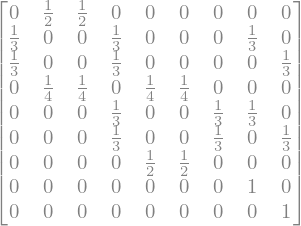

In [6]:
A = sp.Matrix([
#Casilla 0
[0, a, a, 0, 0, 0, 0, 0, 0],
#Casilla 1
[b, 0, 0, b, 0, 0, 0, b, 0],
#Casilla 2
[b, 0, 0, b, 0, 0, 0, 0, b],
#Casilla 3
[0, c, c, 0, c, c, 0, 0, 0],
#Casilla 4
[0, 0, 0, b, 0, 0, b, b, 0],
#Casilla 5
[0, 0, 0, b, 0, 0, b, 0, b],
#Casilla 6
[0, 0, 0, 0, a, a, 0, 0, 0],
#Casilla 7
[0, 0, 0, 0, 0, 0, 0, 1, 0],
#Casilla 8
[0, 0, 0, 0, 0, 0, 0, 0, 1]
])
A

The transition matrix $A$ has dimensions $9\times 9$, corresponding to the nine states of the chain.

In [35]:
A.shape

The transition matrix has dimensions $9\times9$, corresponding to the 9 states of the chain.

Since states $7$ and $8$ are absorbing, states $0,\ldots,6$ are transient.

The matrix $Q$ is obtained by restricting the transition matrix to the transient states:

$$
Q=A_{0:7,0:7}.
$$

This is the transient-to-transient submatrix required to construct the fundamental matrix.

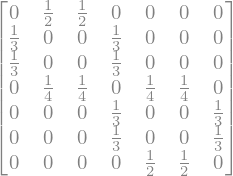

In [8]:
Q = A[:-2, :-2]
Q

States 7 and 8 are absorbing states. Therefore, the transient-state submatrix $Q$ has dimensions $7\times7$.

In [9]:
Q.shape

For an absorbing Markov chain, the fundamental matrix is defined as

$$
N=(I-Q)^{-1}.
$$

Create an identity matrix the same size of $Q$

In [10]:
I = sp.eye(Q.rows)

Calculate $$I-Q$$

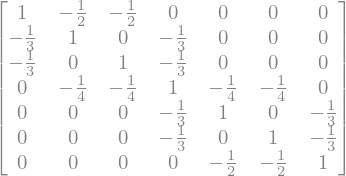

In [39]:
IQ = I - Q
IQ

Calculate $$(I-Q)^{-1}$$

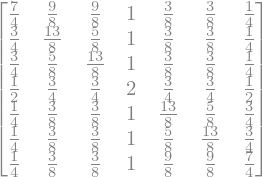

In [40]:
N = IQ.inv()
N

Multiply the matrix $(I-Q)^{-1}$ by the vector with all  $1$ to obtain the vector which $i-th$ entry is the sum of $i-th$ row of $(I-Q)^{-1}$

In [41]:
ones = sp.ones(Q.rows, 1)
t = N * ones
t

Thestimated time to reach an absorvent state starting in state $i$ is the $i-th$ entry of the resultant vector

In [42]:
print("Tiempo esperado desde casilla 0:")
sp.N(t[0], 10)

Tiempo esperado desde casilla 0:


We have solved the problem analytically. Lets solve it through a simulation.

In [43]:
import random as rd

The following function samples the next state according to the transition probabilities of the current state. A uniform random number is generated and the cumulative transition probabilities determine the next state.

In [44]:
def siguiente_estado(estado):
    fila = A.row(estado)

    u = rd.random()
    acumulado = 0

    for j in range(A.cols):
        acumulado += float(fila[j])

        if u <= acumulado:
            return j

Function to simulate a game, starting from state $0$.

In [45]:
def partida():
    estado = 0
    tiros = 0

    while estado != 8 and estado != 7:
        estado = siguiente_estado(estado)
        tiros += 1

    return tiros

Simulate $n$ games and calculate the mean of steps needed to reach an absorvent state.

In [46]:
n = 1000000
suma = 0

for _ in range(n):
    suma += partida()

promedio = suma / n

We print the analytical result and the value obtained through smulation. We also calculate and print the error.

In [47]:
print("Simulado:", promedio)
print("Analítico:", sp.N(t[0]))
print("Error:", abs(promedio - float(sp.N(t[0]))))

Simulado: 6.015438
Analítico: 6.00000000000000
Error: 0.015437999999999619
